In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#task 1:
# Load the dataset
# I just uploaded the csv file to the GitHub repository and read it from there, so you too can access it without any issues.
url_listing_berlin = "https://raw.githubusercontent.com/Nill2nn/Statistical-Programming/refs/heads/Nill2nn-patch-excel/listings_berlin.csv"
listings_berlin = pd.read_csv(url_listing_berlin)

print("listing Berlin shape:", listings_berlin.shape)

# the first few rows of the dataset
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
# I used the above two lines to make sure that all columns are displayed. pandas is truncating the display.
print(listings_berlin.head(10))

# Check for missing values
missing_number = listings_berlin.isnull().sum()
missing_percent = (missing_number/ len(listings_berlin)) * 100

missing_df = pd.DataFrame({
    'Missing in number ': missing_number,
    'Missing in Percentage': missing_percent.round(2)
})

print(missing_df)

listing Berlin shape: (14274, 20)
     price    neighbourhood_cleansed  latitude  longitude        room_type  \
0  $105.00   Prenzlauer Berg Südwest  52.53471   13.41810  Entire home/apt   
1  $135.00   Prenzlauer Berg Südwest  52.53269   13.41805  Entire home/apt   
2   $75.00  Prenzlauer Berg Nordwest  52.54813   13.40366  Entire home/apt   
3   $32.00              Reuterstraße  52.49419   13.42166  Entire home/apt   
4  $202.00   Prenzlauer Berg Südwest  52.53711   13.40888  Entire home/apt   
5      NaN           Brunnenstr. Süd  52.53408   13.38871  Entire home/apt   
6  $152.00           Brunnenstr. Süd  52.53355   13.40476  Entire home/apt   
7   $65.00      Tempelhofer Vorstadt  52.49134   13.37975  Entire home/apt   
8  $260.00            Helmholtzplatz  52.54419   13.41956  Entire home/apt   
9   $70.00  Prenzlauer Berg Nordwest  52.54804   13.40349  Entire home/apt   

   bedrooms bathrooms_text  accommodates  \
0       1.0         1 bath             2   
1       4.0      2.

In [94]:
"""
 the three value with the highest percentage of missing values are: 'price', 'host_response_rate' and 'review_scores' for rating and cleanliness.
I will keep and impute price column, because pricing information is crucial for our analysis and dropping it would lead to a significant loss of valuable insights. Instead, I will impute the missing values in the price column using the median price of the listings, which is a common approach for handling missing numerical data.
I will drop the 'host_response_rate' column because it has a high percentage of missing values and may not be essential for our analysis. The 'host_response_rate' won't actually play a significant role in decision-making of customers.
I will keep the missing values in the 'review_scores' for rating and cleanliness columns, as they may still provide valuable insights for customers . we could not impute these values because they are random and imputing them with mean or median could lead to misleading information.
"""

"\n the three value with the highest percentage of missing values are: 'price', 'host_response_rate' and 'review_scores' for rating and cleanliness.\nI will keep and impute price column, because pricing information is crucial for our analysis and dropping it would lead to a significant loss of valuable insights. Instead, I will impute the missing values in the price column using the median price of the listings, which is a common approach for handling missing numerical data.\nI will drop the 'host_response_rate' column because it has a high percentage of missing values and may not be essential for our analysis. The 'host_response_rate' won't actually play a significant role in decision-making of customers.\nI will keep the missing values in the 'review_scores' for rating and cleanliness columns, as they may still provide valuable insights for customers . we could not impute these values because they are random and imputing them with mean or median could lead to misleading information.\

In [95]:
#Task 3:
#cleaning the price column by removing the $ sign and converting it to numeric
def clean_price(price_str):
    if pd.isna(price_str):
        return None
    if isinstance(price_str, str):
        return float(price_str.replace('$', '').replace(',', ''))
    return float(price_str)

listings_berlin['price'] = listings_berlin['price'].apply(clean_price)
print(listings_berlin['price'].describe())  # with .describe methode we can check minimum, median(50%), mean, and maximum

#task 4:
#Turning the bathrooms_text column into a numeric column called bathrooms
listings_berlin['bathrooms_text'].value_counts()


def clean_baths(bathroom):
    if pd.isna(bathroom):
        return None

    bathroom = str(bathroom).lower()

    if 'half' in bathroom:
        return 0.5
    else:
        numpart = bathroom.split(' ')[0]
        return float(numpart)


listings_berlin['bathrooms'] = listings_berlin['bathrooms_text'].apply(clean_baths)
print('The Types of rooms available:', listings_berlin['bathrooms'].unique())

count     9264.000000
mean       201.240393
std       1656.989769
min          5.000000
25%         70.000000
50%        104.000000
75%        160.000000
max      50000.000000
Name: price, dtype: float64
The Types of rooms available: [ 1.   2.5  2.   1.5  0.   nan  3.   0.5  4.5  8.   3.5  5.   8.5  4.
  6.  15. ]


In [96]:
#Task 5:
#Turning T/F into boolean values
listings_berlin['host_is_superhost'] = listings_berlin['host_is_superhost'] == 't'
listings_berlin['instant_bookable'] = listings_berlin['instant_bookable'] == 't'

print(listings_berlin['host_is_superhost'].dtype)
print(listings_berlin['instant_bookable'].dtype)
print(listings_berlin['host_is_superhost'].unique())

#The number of years the host join Airbnb
lb = listings_berlin.copy()
lb['host_tenure_years'] = 2025 - pd.to_datetime(lb['host_since']).dt.year
print(lb['host_tenure_years'].head(5))

bool
bool
[False  True]
0    17.0
1    16.0
2    16.0
3    15.0
4    15.0
Name: host_tenure_years, dtype: float64


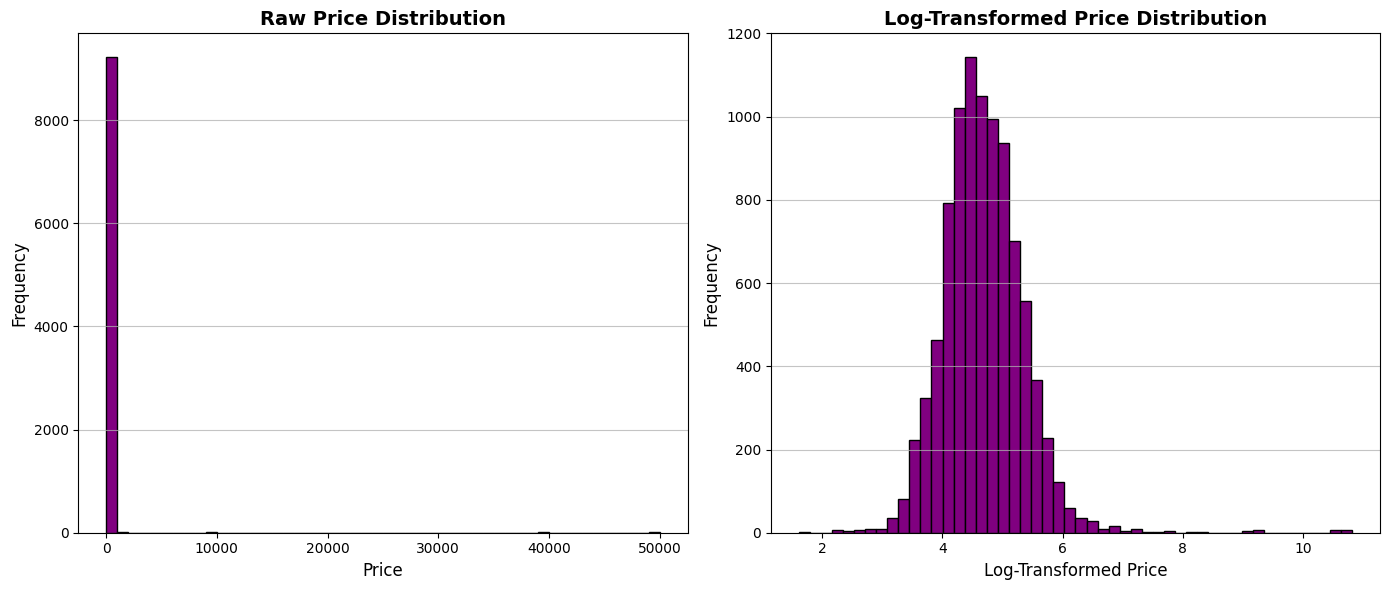

' explanation: The raw price is skewed due to outliers, making it hard to analyze and showing undesirable statistical properties.\nLog transformation fixes this by creating a bell curve, which is much more suitable for statistical analysis.\nWith a normal distribution, our data is ready to be analyzed.'

In [97]:
#Task 6:
#comparing the distribution of raw price and log-transformed price

plt.figure(figsize=(14, 6))

# Raw price distribution
plt.subplot(1, 2, 1)
plt.hist(listings_berlin['price'], bins=50, color='purple', edgecolor='black')
plt.title('Raw Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)

# Log-transformed price distribution
plt.subplot(1, 2, 2)
plt.hist(np.log(listings_berlin['price']), bins=50, color='purple', edgecolor='black')
plt.title('Log-Transformed Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Log-Transformed Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

""" explanation: The raw price is skewed due to outliers, making it hard to analyze and showing undesirable statistical properties.
Log transformation fixes this by creating a bell curve, which is much more suitable for statistical analysis.
With a normal distribution, our data is ready to be analyzed."""

#task 7:

In [98]:
#task 7:
# sorting the neighborhoods_cleansed column by  median price in descending order
neighborhood_summary = (listings_berlin.groupby('neighbourhood_cleansed').agg(
    count=('neighbourhood_cleansed', 'count'),
    median_price=('price', 'median'),
    mean_rating=('review_scores_rating', 'mean')
).round(2).sort_values('median_price', ascending=False))

print(neighborhood_summary.head(3))
""" The top three neighborhoods with the highest median price are:
 1. Haselhorst with a median price of 236.5 and average rating of 4.86
 2. West 5 with a median price of 203 and average rating of 4.79
 3. Schmargendorf  with a median price of 172 and average rating of 4.66 """

# Task 8:
# calculating the trimmed mean of the price column by removing the top and bottom 5% of the data.
def trimmed_mean(x, pct):
    x = sorted(x)
    n = int(len(x) * (pct / 100))
    for i in range(n):
        del x[0]
        del x[-1]
    return sum(x) / len(x)

cleaned_prices = listings_berlin['price'].dropna().to_numpy()
trim_m = trimmed_mean(cleaned_prices, 5)
arith_m = cleaned_prices.mean()
compare = trim_m / arith_m

print(f'Trimmed mean: {trim_m}')
print(f'Arithmetic mean: {arith_m}')
print(f'Comparison: {compare}')

""" We define a function trimmed_mean with 2 parameters: x - list of numbers, pct - percentage
    We sort the list x and calculate n - number of elements to remove from each side.
    We use a loop to remove n smallest and n largest elements from the list and return the mean.
    Finally we compare the trimmed mean to the arithmetic mean."""

                        count  median_price  mean_rating
neighbourhood_cleansed                                  
Haselhorst                  6         236.5         4.86
West 5                     14         203.0         4.79
Schmargendorf              43         172.0         4.66
Trimmed mean: 119.55121132165986
Arithmetic mean: 201.24039291882556
Comparison: 0.5940716452977872


' We define a function trimmed_mean with 2 parameters: x - list of numbers, pct - percentage\n    We sort the list x and calculate n - number of elements to remove from each side.\n    We use a loop to remove n smallest and n largest elements from the list and return the mean.\n    Finally we compare the trimmed mean to the arithmetic mean.'

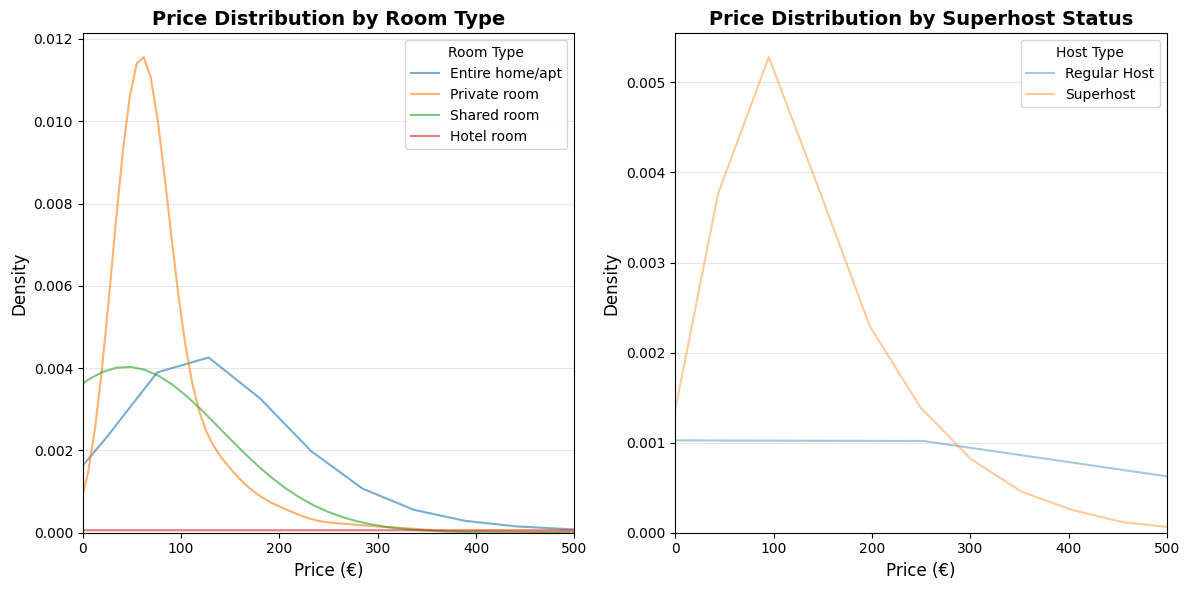

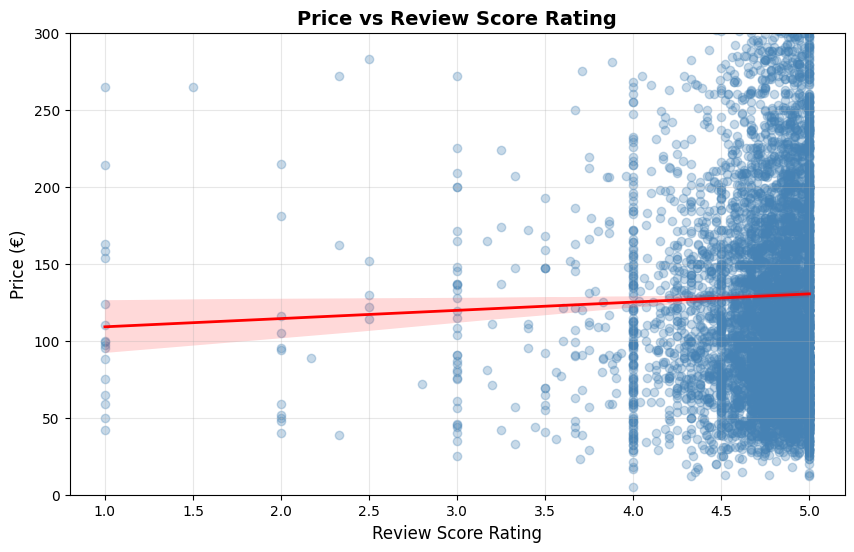

In [99]:
#task 9:
#drawing plots to show the relationship between price and room_type, price and host status and price and review_score_rating
plt.figure(figsize=(12, 6))
# Price vs room_type
plt.subplot(1, 2, 1)
# gathering and collecting the prices of each type of room together to plot them in the same graph
for room in listings_berlin['room_type'].unique():
    subset = listings_berlin[listings_berlin['room_type'] == room]
    sns.kdeplot(subset['price'], label=room, fill=False, alpha=0.6)

plt.title('Price Distribution by Room Type', fontsize=14, fontweight='bold')
plt.xlabel('Price (€)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 500)
plt.legend(title='Room Type')
plt.grid(axis='y', alpha=0.3)

#  to compare the price distribution between superhosts and regular hosts
plt.subplot(1, 2, 2)

for superhost in listings_berlin['host_is_superhost'].unique():
    subset = listings_berlin[listings_berlin['host_is_superhost'] == superhost]
    label = 'Superhost' if superhost == True else 'Regular Host'
    sns.kdeplot(subset['price'], label=label, fill=False, alpha=0.4)

plt.title('Price Distribution by Superhost Status', fontsize=14, fontweight='bold')
plt.xlabel('Price (€)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 500)
plt.legend(title='Host Type')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Price vs review_score_rating
plt.figure(figsize=(10, 6))
# Remove missing values
data_clean = listings_berlin.dropna(subset=['review_scores_rating', 'price'])
# Remove extreme price outliers
data_clean = data_clean[data_clean['price'] < 500]
# Remove zeros in review scores
data_clean = data_clean[data_clean['review_scores_rating'] > 0]
sns.regplot(data=data_clean, x='review_scores_rating', y='price',
            scatter_kws={'alpha': 0.3, 'color': 'steelblue'},  # change to steelblue
            line_kws={'color': 'red', 'linewidth': 2})
plt.xlabel('Review Score Rating', fontsize=12)
plt.ylabel('Price (€)', fontsize=12)
plt.ylim(0, 300)
plt.title('Price vs Review Score Rating', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

In [100]:
#Task11
import json
with open('berlin_bezirke.geojson', 'r', encoding='utf-8') as f:
    berlin_geojson = json.load(f)
    bzr = []
#extract the property 'BZR_NAME' from each feature in the GeoJSON and append it to the list bzr
for feature in berlin_geojson['features']:
    bzr.append(feature['properties']['BZR_NAME'])
#create a set of bzr and a set of unique values from the 'neighbourhood_cleansed' column to identify intersections and differences 
bzr_set = set(bzr)
airbnb_set = set(listings_berlin['neighbourhood_cleansed'].unique())
matched = bzr_set & airbnb_set
only_in_bzr = bzr_set - airbnb_set
only_in_airbnb = airbnb_set - bzr_set
print('Matched:', len(matched))
#function to normalize the elements(lowercase, remove extra spaces) and apply for both sets
def normalize(name):
    return(name.lower().strip(' /-*,')
           .replace('str.','straße')
           .replace('strasse','straße')
           .replace('ss', 'ß')
           .replace('-', ' ')
           .replace('/',' '))
#add new column in df and apply normalization function for both sets and find unmatched values again
listings_berlin['neighbourhood_norm'] = listings_berlin['neighbourhood_cleansed'].apply(normalize)
bzr_normalized = [normalize(name) for name in bzr]
still_unmatched = set(listings_berlin['neighbourhood_norm']) - set(bzr_normalized)
also_unm = set(bzr_normalized) - set(listings_berlin['neighbourhood_norm'])
#print a list of unmatched values in airbnb list
print("Airbnb unmatched:")
for name in sorted(still_unmatched):
    print(f"  '{name}'")
#the same for json file
print("\nGeoJSON unmatched:")
for name in sorted(also_unm):
    print(f"  '{name}'")
#manually create a mapping for the remaining values and apply it to new norm column in df
matched_names = {'alt  treptow': 'alt treptow', 'friedenau': 'friedenau ost', 'friedenau': 'friedenau west', 'gatow   kladow': 'gatow kladow', 'gropiußtadt': 'gropiußtadt ost', 'gropiußtadt': 'gropiußtadt west', 'kölln. vorstadt spindlersf.': 'köllnische vorstadt spindlersfeld', 'lichtenrade': 'lichtenrade nord',
                 'lichtenrade': 'lichtenrade süd',  'mariendorf': 'mariendorf nord', 'mariendorf': 'mariendorf süd', 'marienfelde': 'marienfelde nord', 'marienfelde': 'marienfelde süd', 'mv 1': 'mv nord', 'mv 2': 'mv süd', 'nord 1': 'nord 1   frohnau hermsdorf', 'nord 2': 'nord 2   waidmannslust wittenau lübars', 
                 'ost 1': 'ost 1   reginhardstraße', 'ost 2': 'ost 2   alt reinickendorf', 'otto suhr allee': 'otto suhr allee kantstraße', 'rahnsdorf heßenwinkel': 'rahnsdorf', 'schmöckwitz karolinenhof rauchfangswerder': 'schmöckwitz', 'schöneberg nord': 'schöneberg nordost', 'schöneberg nord': 'schöneberg nordwest',
                 'schöneberg süd': 'schöneberg südost', 'schöneberg süd': 'schöneberg südwest', 'südliche friedrichstadt': 'südliche  friedrichstadt', 
                 'tempelhof': 'tempelhof nord', 'tempelhof': 'tempelhof südost', 'tempelhof': 'tempelhof südwest', 'west 1': 'west 1   tegel süd flughafensee', 'west 2': 'west 2   heiligensee konradshöhe', 'west 3': 'west 3   borsigwalde freie scholle', 'west 4': 'west 4   auguste viktoria allee', 'west 5': 'west 5   tegel',
                 'zehlendorf  nord': 'zehlendorf nord', 'zehlendorf  südwest': 'zehlendorf südwest'
}
listings_berlin['neighbourhood_norm'] = listings_berlin['neighbourhood_norm'].replace(matched_names)
still_unmatched = set(listings_berlin['neighbourhood_norm']) - set(bzr_normalized)
#convert json list to df and merge with airbnb df to see the matched and unmatched values
geo_df = pd.DataFrame([
    {  'bzr_norm': normalize(f['properties']['BZR_NAME'])}
    for f in berlin_geojson['features']])
merged = listings_berlin.merge(geo_df,
                    left_on='neighbourhood_norm',
                    right_on='bzr_norm',
                    how='left')
merged.head(10)
total_geo = len(bzr_set)
total_airbnb = len(airbnb_set)
matched = len(set(bzr_normalized) & set(listings_berlin['neighbourhood_norm']))
unmatched_geo = len(set(bzr_normalized) - set(listings_berlin['neighbourhood_norm']))
unmatched_airbnb = len(set(listings_berlin['neighbourhood_norm']) - set(bzr_normalized))

print(f"Total GeoJSON regions:     {total_geo}")
print(f"Total Airbnb regions:      {total_airbnb}")
print(f"Successfully matched:      {matched}")
print(f"Unmatched in GeoJSON:      {unmatched_geo}")
print(f"Unmatched in Airbnb:       {unmatched_airbnb}")

'''"After normalization (expanding abbreviations, fixing hyphens and whitespace) and manual mapping of edge cases, 129 out of 138 Airbnb 
regions were successfully matched to GeoJSON regions (93%). 9 Airbnb regions remain unmatched, likely due to naming conventions with no 
clear GeoJSON equivalent. 13 GeoJSON regions have no corresponding Airbnb listings."'''
print()

Matched: 81
Airbnb unmatched:
  'alt  treptow'
  'altstadt kietz'
  'barstraße'
  'düßeldorfer straße'
  'forst grunewald'
  'friedenau'
  'gatow   kladow'
  'gropiußtadt'
  'heerstraße nord'
  'kantstraße'
  'kurfürstendamm'
  'kölln. vorstadt spindlersf.'
  'lichtenrade'
  'mariendorf'
  'marienfelde'
  'mv 1'
  'mv 2'
  'neue kantstraße'
  'nord 1'
  'nord 2'
  'ost 1'
  'ost 2'
  'otto suhr allee'
  'rahnsdorf heßenwinkel'
  'schmöckwitz karolinenhof rauchfangswerder'
  'schöneberg nord'
  'schöneberg süd'
  'südliche friedrichstadt'
  'tempelhof'
  'west 1'
  'west 2'
  'west 3'
  'west 4'
  'west 5'
  'wiesbadener straße'
  'zehlendorf  nord'
  'zehlendorf  südwest'

GeoJSON unmatched:
  'alt treptow'
  'altstadt köpenick'
  'britz nord'
  'friedenau ost'
  'friedenau west'
  'gatow kladow'
  'gropiußtadt ost'
  'gropiußtadt west'
  'köllnische vorstadt spindlersfeld'
  'lichtenrade nord'
  'lichtenrade süd'
  'lietzenburger straße'
  'mariendorf nord'
  'mariendorf süd'
  'marie

In [101]:
#task12
group_by_bzr = merged.groupby('neighbourhood_norm')
#merged['price'] = merged['price'].str.replace('$', '').str.replace(',', '').astype(float)
group_by_bzr = group_by_bzr.agg(num_listings=('price', 'count'), median_price=('price', 'median'))
group_by_bzr = group_by_bzr.reset_index()
group_by_bzr.columns
#added a column with original names without normalization to use it in hover data of the map
group_by_bzr = group_by_bzr.merge(merged[['neighbourhood_norm','neighbourhood_cleansed']].drop_duplicates(),
    on='neighbourhood_norm')
#add a new column in json file with normalized names to use it as featureidkey in the map and match with the df
for feature in berlin_geojson["features"]:
    feature["properties"]["match_key"] = normalize(feature["properties"]["BZR_NAME"])
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
fig = px.choropleth(group_by_bzr, geojson = berlin_geojson, locations = 'neighbourhood_norm', color = 'median_price', featureidkey='properties.match_key', hover_name='neighbourhood_cleansed',
    hover_data={'neighbourhood_norm': False,'median_price': True, 'num_listings': False},
    title='Median Nightly Airbnb Price by Berlin District', color_continuous_scale='GnBu',  labels={'median_price': 'Median Nightly Price (€)'} )
fig.update_geos(fitbounds='locations', visible=False)
fig.show()

In [102]:
#task13
#with function transform we calculated the median and added it for each listing
import plotly.io as pio
pio.renderers.default = "browser"
merged['median_price_bzr'] = (merged.groupby('neighbourhood_norm')['price']
    .transform('median'))
merged['above_median'] = merged['price'] > merged['median_price_bzr']
merged['price_vs_median'] = merged['above_median'].map({
    True: 'Above median',
    False: 'Below median'})
merged.head(10)
#merged['above_median'] = merged['price'] > merged['median_price_bzr']
fig = px.choropleth(group_by_bzr, geojson = berlin_geojson, locations = 'neighbourhood_norm', color = 'median_price', featureidkey='properties.match_key', hover_name='neighbourhood_cleansed',
    hover_data={'neighbourhood_norm': False,'median_price': True, 'num_listings': False},
    title='Median Nightly Airbnb Price by Berlin District', color_continuous_scale='GnBu',  labels={'median_price': 'Median Nightly Price (€)'} )
fig.update_geos(fitbounds='locations', visible=False)

scatter = px.scatter_geo(
    merged,
    lat='latitude',
    lon='longitude',
    color='price_vs_median',
    hover_name='neighbourhood_cleansed',
    hover_data={
        'price': True,
        'median_price_bzr': True},
         color_discrete_map={
        'Above median': "#eac611",
        'Below median': "#dc6be2"
    })
for trace in scatter.data:
    fig.add_trace(trace)
fig.update_layout(
    legend=dict(
        x=1.02,
        y=1.0),
    coloraxis_colorbar=dict(
        title='Median Nightly Price (€)',
        x=0.88,
        y=0.5,
        len=0.75))
fig.show()

In [103]:
#Task14
areas = []
for feature in berlin_geojson["features"]:
    areas.append({"neighbourhood_norm": normalize(feature["properties"]["BZR_NAME"]),
        "area_m2": feature["properties"]["GROESSE_m2"]})
areas_df = pd.DataFrame(areas)
group_by_bzr = group_by_bzr.merge(areas_df, on='neighbourhood_norm', how='left')
group_by_bzr['density'] = (group_by_bzr['num_listings']) / (group_by_bzr['area_m2'] / 1000000)
fig = px.choropleth(group_by_bzr, geojson = berlin_geojson, locations = 'neighbourhood_norm', color = 'density', featureidkey='properties.match_key', hover_name='neighbourhood_cleansed',
    hover_data={'neighbourhood_norm': False,'median_price': False, 'num_listings': True},
    title='Airbnb Listing Density by Berlin District (listings per km²)', color_continuous_scale='tealrose',  labels={'num_listings': 'Number of Listings'} )
fig.update_geos(fitbounds='locations', visible=False)
fig.show()

In [104]:
density_sorted = group_by_bzr.sort_values('density', ascending=False).set_index('neighbourhood_norm')
density_sorted.head(10)

,num_listings,median_price,neighbourhood_cleansed,area_m2,density
neighbourhood_norm,,,,,
brunnenstraße süd,402,145.5,Brunnenstr. Süd,1755172.262,229.037348
helmholtzplatz,157,119.0,Helmholtzplatz,711300.072,220.722598
prenzlauer berg südwest,290,144.0,Prenzlauer Berg Südwest,1370146.504,211.656198
südliche luisenstadt,242,101.0,südliche Luisenstadt,1496159.370,161.747475
schöneberg nordwest,212,85.0,Schöneberg-Nord,1479646.031,143.277511
schöneberg südwest,163,103.0,Schöneberg-Süd,1150671.937,141.656362
reuterstraße,181,90.0,Reuterstraße,1426230.513,126.907957
frankfurter allee nord,156,104.5,Frankfurter Allee Nord,1280543.206,121.823301
prenzlauer berg süd,197,125.0,Prenzlauer Berg Süd,1660928.148,118.608382


In [105]:
prices_sorted = group_by_bzr.sort_values('median_price', ascending=False).set_index('neighbourhood_norm')
prices_sorted.head(10)  

,num_listings,median_price,neighbourhood_cleansed,area_m2,density
neighbourhood_norm,,,,,
haselhorst,6,236.5,Haselhorst,4693583.382,1.278341
west 5 tegel,11,203.0,West 5,2392477.977,4.597743
schmargendorf,34,172.0,Schmargendorf,4082997.289,8.327216
regierungsviertel,98,159.0,Regierungsviertel,2695388.947,36.358389
brunnenstraße nord,161,150.0,Brunnenstr. Nord,3320296.446,48.489646
brunnenstraße süd,402,145.5,Brunnenstr. Süd,1755172.262,229.037348
prenzlauer berg südwest,290,144.0,Prenzlauer Berg Südwest,1370146.504,211.656198
alexanderplatz,725,142.0,Alexanderplatz,6228829.686,116.394256
tiergarten süd,115,139.0,Tiergarten Süd,5171032.456,22.239273


In [106]:
'''Interpretation for the task: The highest listing densities occur in central Bezirksregionen such as Brunnenstraße Süd, Helmholtzplatz, and Prenzlauer Berg Südwest. 
The highest median prices are found in Haselhorst, West 5 Tegel, and Schmargendorf. However, these areas have very few listings, which likely inflates the median price and makes the estimate 
less reliable compared to regions with a larger number of listings.'''



'Interpretation for the task: The highest listing densities occur in central Bezirksregionen such as Brunnenstraße Süd, Helmholtzplatz, and Prenzlauer Berg Südwest. \nThe highest median prices are found in Haselhorst, West 5 Tegel, and Schmargendorf. However, these areas have very few listings, which likely inflates the median price and makes the estimate \nless reliable compared to regions with a larger number of listings.'